# 🎯 NEXUS Stock AI — Phases 23 & 24
## Bayesian Hyperparameter Optimization (Optuna) & Probability Calibration (Platt Scaling)

**Objective:** Maximize out-of-sample generalization of our champion **Experiment C (Price + News Multi-Modal XGBoost)** model before production backtesting.

### 🔬 Phases Implemented:
1. **Phase 24 — Optuna Bayesian Optimization (50 Trials):**
   - Chronological temporal split: Train (2018–2021, 8,241 rows), Validation (2022, 1,757 rows), Test (2023, 1,736 rows).
   - Search space engineered with strict financial regularization: shallow trees (`max_depth: 2 to 5`), conservative learning rates (`0.01 to 0.1`), feature/row subsampling (`0.5 to 0.9`), and strong L1/L2 shrinkage (`reg_alpha` and `reg_lambda`: 0.1 to 10.0).
   - Objective metric: Out-of-sample **Validation ROC-AUC** across the 2022 bear market.
2. **Phase 23 — Probability Calibration:**
   - Tree-based models produce uncalibrated log-odds that can distort position sizing and risk thresholds.
   - Train base `XGBClassifier` with Optuna best parameters on the Train set.
   - Fit `CalibratedClassifierCV` via Platt scaling (Sigmoid) on the **independent Validation set (2022)** using `cv='prefit'` (guaranteeing zero data leakage).
   - Evaluate reliability curves and Brier score loss.
3. **Out-of-Sample Evaluation & Artifact Replacement:**
   - Test calibrated model on the **2023 Out-of-Sample Test set** (1,736 rows).
   - Save calibrated artifact as `xgb_direction_calibrated.joblib` and update `model_metadata.json`.
   - Regenerate global `shap_summary_plot.png`.
   - Verify standalone production inference via `NexusInferenceEngine`.

### ⚙️ Step 1: Environment Setup & Data Loading

In [10]:
# Install ML dependencies
%pip install -q xgboost scikit-learn optuna joblib shap pyarrow matplotlib seaborn

import os
import sys
import gc
import time
import json
import shutil
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
import optuna
import joblib
import shap

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, brier_score_loss, confusion_matrix, classification_report
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Mount Google Drive if in Colab
try:
    from google.colab import drive
    print("Mounting Google Drive at /content/drive...")
    drive.mount("/content/drive")
    print("✓ Google Drive mounted successfully.")
except Exception as e:
    print(f"Drive mount note: {e}")

# Resolve paths
GDRIVE_DIR = "/content/drive/MyDrive/NEXUS_Stock_AI/data"
LOCAL_DIR = "./data"

def resolve_path(filename):
    candidates = [
        os.path.join(GDRIVE_DIR, filename),
        os.path.join(LOCAL_DIR, filename),
        filename
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    return candidates[0]

DATASET_PATH = resolve_path("model_dataset_v1.parquet")
print(f"Target Dataset Path: {DATASET_PATH} (Exists: {os.path.exists(DATASET_PATH)})")

# Load feature schema
schema_path = resolve_path("../models/feature_schema.json") if not os.path.exists("./models/feature_schema.json") else "./models/feature_schema.json"
if not os.path.exists(schema_path):
    schema_path = "/content/drive/MyDrive/NEXUS_Stock_AI/models/feature_schema.json"

with open(schema_path, "r", encoding="utf-8") as f:
    schema_data = json.load(f)
FEATURE_COLS = schema_data["features"] if isinstance(schema_data, dict) else schema_data
print(f"✓ Loaded feature schema ({len(FEATURE_COLS)} features): {FEATURE_COLS}")


Mounting Google Drive at /content/drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted successfully.
Target Dataset Path: /content/drive/MyDrive/NEXUS_Stock_AI/data/model_dataset_v1.parquet (Exists: True)
✓ Loaded feature schema (23 features): ['return_1d', 'return_3d', 'return_5d', 'sma_5', 'sma_20', 'sma_50', 'ema_12', 'ema_26', 'macd', 'macd_signal', 'rsi_14', 'volatility_5d', 'volatility_20d', 'volume_change_1d', 'volume_sma_20', 'news_count', 'sentiment_mean', 'sentiment_std', 'sentiment_min', 'sentiment_max', 'positive_ratio', 'negative_ratio', 'neutral_ratio']


### 📅 Step 2: Chronological Temporal Splits (Zero-Leakage) & Feature Partitioning

- **Dataset Filter:** Restrict to $\ge \text{2018-01-01}$ for dense FinBERT headline coverage.
- **Partitions:**
  - **Train:** 2018-01-01 to 2021-12-31 (4 Years, Bull Market & COVID shock)
  - **Validation:** 2022-01-01 to 2022-12-31 (1 Year, Severe Bear Market / Rate Hikes) — Used for **Optuna optimization** and **Calibration fitting**
  - **Test:** 2023-01-01 to 2023-12-31 (1 Year, Bull Recovery) — Held-out Out-of-Sample Test set

In [11]:
print("=" * 80)
print("PHASE 15: CHRONOLOGICAL TEMPORAL SPLIT")
print("=" * 80)

df = pd.read_parquet(DATASET_PATH)
df['date'] = pd.to_datetime(df['date']).dt.normalize()
print(f"Loaded full dataset: {len(df):,} rows ({df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')})")

# Filter from 2018-01-01 onward
df_filtered = df[df['date'] >= '2018-01-01'].sort_values(['date', 'stock_symbol']).reset_index(drop=True)
print(f"Filtered dataset (>= 2018-01-01): {len(df_filtered):,} rows")

# Temporal slices
train_mask = df_filtered['date'] < '2022-01-01'
val_mask = (df_filtered['date'] >= '2022-01-01') & (df_filtered['date'] < '2023-01-01')
test_mask = df_filtered['date'] >= '2023-01-01'

X_train = df_filtered.loc[train_mask, FEATURE_COLS].copy()
y_train = df_filtered.loc[train_mask, 'target'].astype(int).values

X_val = df_filtered.loc[val_mask, FEATURE_COLS].copy()
y_val = df_filtered.loc[val_mask, 'target'].astype(int).values

X_test = df_filtered.loc[test_mask, FEATURE_COLS].copy()
y_test = df_filtered.loc[test_mask, 'target'].astype(int).values

# Verify clean inputs
assert not X_train.isna().any().any(), "NaNs found in X_train!"
assert not X_val.isna().any().any(), "NaNs found in X_val!"
assert not X_test.isna().any().any(), "NaNs found in X_test!"

split_summary = pd.DataFrame([
    {
        "Split": "Train (2018–2021)",
        "Date Range": f"{df_filtered.loc[train_mask, 'date'].min().strftime('%Y-%m-%d')} to {df_filtered.loc[train_mask, 'date'].max().strftime('%Y-%m-%d')}",
        "Samples": len(X_train),
        "Percentage": f"{len(X_train) / len(df_filtered):.1%}",
        "Target UP Ratio": f"{y_train.mean():.2%}"
    },
    {
        "Split": "Validation (2022)",
        "Date Range": f"{df_filtered.loc[val_mask, 'date'].min().strftime('%Y-%m-%d')} to {df_filtered.loc[val_mask, 'date'].max().strftime('%Y-%m-%d')}",
        "Samples": len(X_val),
        "Percentage": f"{len(X_val) / len(df_filtered):.1%}",
        "Target UP Ratio": f"{y_val.mean():.2%}"
    },
    {
        "Split": "Test (2023)",
        "Date Range": f"{df_filtered.loc[test_mask, 'date'].min().strftime('%Y-%m-%d')} to {df_filtered.loc[test_mask, 'date'].max().strftime('%Y-%m-%d')}",
        "Samples": len(X_test),
        "Percentage": f"{len(X_test) / len(df_filtered):.1%}",
        "Target UP Ratio": f"{y_test.mean():.2%}"
    }
])
display(split_summary)


PHASE 15: CHRONOLOGICAL TEMPORAL SPLIT
Loaded full dataset: 66,865 rows (1980-05-27 to 2023-12-27)
Filtered dataset (>= 2018-01-01): 11,734 rows


,Split,Date Range,Samples,Percentage,Target UP Ratio
0,Train (2018–2021),2018-01-02 to 2021-12-31,8241,70.2%,53.17%
1,Validation (2022),2022-01-03 to 2022-12-30,1757,15.0%,46.73%
2,Test (2023),2023-01-03 to 2023-12-27,1736,14.8%,55.36%


### 🔬 Step 3: Pre-Tuning Benchmark Evaluation (Default Experiment C)
Evaluate the un-tuned multi-modal model to establish the exact baseline performance to beat.

In [12]:
print("=" * 80)
print("BENCHMARK: UN-TUNED EXPERIMENT C (DEFAULT HYPERPARAMETERS)")
print("=" * 80)

default_params = {
    "n_estimators": 300,
    "max_depth": 5,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "eval_metric": "logloss",
    "tree_method": "hist"
}

default_model = xgb.XGBClassifier(**default_params, early_stopping_rounds=20)
default_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Validation predictions
val_probs_def = default_model.predict_proba(X_val)[:, 1]
val_auc_def = roc_auc_score(y_val, val_probs_def)

# Test predictions
test_probs_def = default_model.predict_proba(X_test)[:, 1]
test_preds_def = (test_probs_def >= 0.5).astype(int)
test_auc_def = roc_auc_score(y_test, test_probs_def)
test_f1_def = f1_score(y_test, test_preds_def)
test_acc_def = accuracy_score(y_test, test_preds_def)
test_brier_def = brier_score_loss(y_test, test_probs_def)

print(f"Validation ROC-AUC (Default): {val_auc_def:.4f}")
print(f"Test ROC-AUC       (Default): {test_auc_def:.4f}")
print(f"Test F1-Score      (Default): {test_f1_def:.4f}")
print(f"Test Accuracy      (Default): {test_acc_def:.4f}")
print(f"Test Brier Score   (Default): {test_brier_def:.4f}")


BENCHMARK: UN-TUNED EXPERIMENT C (DEFAULT HYPERPARAMETERS)
Validation ROC-AUC (Default): 0.5119
Test ROC-AUC       (Default): 0.5179
Test F1-Score      (Default): 0.7130
Test Accuracy      (Default): 0.5553
Test Brier Score   (Default): 0.2475


### 🧠 Step 4: Phase 24 — Optuna Bayesian Optimization (50 Trials)

We employ the **Tree-structured Parzen Estimator (TPE)** sampler in Optuna to explore a heavily regularized hyperparameter search space:
- `n_estimators`: 100 to 500 (step 50)
- `max_depth`: 2 to 5 (shallow trees to prevent memorizing market noise)
- `learning_rate`: 0.01 to 0.1 (logarithmic scale)
- `min_child_weight`: 3 to 15 (requires sufficient sample support per leaf)
- `subsample` & `colsample_bytree`: 0.5 to 0.9 (stochastic bagging across rows and features)
- `gamma`: 0.1 to 5.0 (minimum loss reduction required for split partitioning)
- `reg_alpha` (L1) & `reg_lambda` (L2): 0.1 to 10.0 (logarithmic shrinkage)
- **Optimization Target:** Maximize out-of-sample **Validation ROC-AUC (2022)**.

In [13]:
print("=" * 80)
print("PHASE 24: OPTUNA BAYESIAN HYPERPARAMETER OPTIMIZATION (50 TRIALS)")
print("=" * 80)

# Mute verbose optuna logs for clean progress
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
        "max_depth": trial.suggest_int("max_depth", 2, 5),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 3, 15),
        "subsample": trial.suggest_float("subsample", 0.5, 0.9, step=0.05),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.9, step=0.05),
        "gamma": trial.suggest_float("gamma", 0.1, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.1, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        "random_state": 42,
        "eval_metric": "logloss",
        "tree_method": "hist"
    }
    
    model = xgb.XGBClassifier(**params, early_stopping_rounds=25)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    val_probs = model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, val_probs)
    return val_auc

# Initialize TPE study
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("Starting 50 Bayesian optimization trials...")
t0 = time.time()
study.optimize(objective, n_trials=50, timeout=1800, show_progress_bar=True)
elapsed = time.time() - t0

print(f"\n✓ Optimization completed in {elapsed:.1f}s ({elapsed / 60:.2f} min).")
print(f"🏆 Best Trial #{study.best_trial.number}: Validation ROC-AUC = {study.best_value:.4f}")
print(f"Improvement over default Validation AUC: {study.best_value - val_auc_def:+.4f}")

best_params = study.best_params
best_params.update({
    "random_state": 42,
    "eval_metric": "logloss",
    "tree_method": "hist"
})

print("\n--- BEST OPTUNA HYPERPARAMETERS ---")
for k, v in sorted(best_params.items()):
    print(f"  {k:20s}: {v}")


PHASE 24: OPTUNA BAYESIAN HYPERPARAMETER OPTIMIZATION (50 TRIALS)
Starting 50 Bayesian optimization trials...


  0%|          | 0/50 [00:00<?, ?it/s]


✓ Optimization completed in 7.8s (0.13 min).
🏆 Best Trial #40: Validation ROC-AUC = 0.5194
Improvement over default Validation AUC: +0.0075

--- BEST OPTUNA HYPERPARAMETERS ---
  colsample_bytree    : 0.55
  eval_metric         : logloss
  gamma               : 2.9794742641306153
  learning_rate       : 0.07587678337146855
  max_depth           : 5
  min_child_weight    : 14
  n_estimators        : 100
  random_state        : 42
  reg_alpha           : 0.12942147572978885
  reg_lambda          : 2.4250546581954646
  subsample           : 0.7
  tree_method         : hist


### 🎯 Step 5: Phase 23 — Probability Calibration (Platt Scaling vs Isotonic)

- **The Problem:** Raw tree ensemble predicted probabilities are uncalibrated (often distorted toward extremes or suppressed in noisy regimes).
- **The Solution:** Map predicted scores into calibrated empirical win rates without shifting the rank order.
- **Zero-Leakage Calibration:** Train the base model on `X_train, y_train`. Then fit `CalibratedClassifierCV` strictly on the **independent Validation set (2022)** using `cv='prefit'`.
- We compare **Platt Scaling (Sigmoid)** vs **Isotonic Regression** using the **Brier Score Loss** (lower is better).

PHASE 23: PROBABILITY CALIBRATION (PLATT SCALING VS ISOTONIC)


/usr/local/lib/python3.13/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


,Method,Val Brier Score,Val ROC-AUC
0,Uncalibrated (Tuned XGBoost),0.252734,0.519415
1,Platt Scaling (Sigmoid),0.248640,0.519415
2,Isotonic Regression,0.248253,0.523338



🏆 Champion Selected: Platt Scaling (Sigmoid) — Smooth monotonic calibration preferred for financial probabilities.


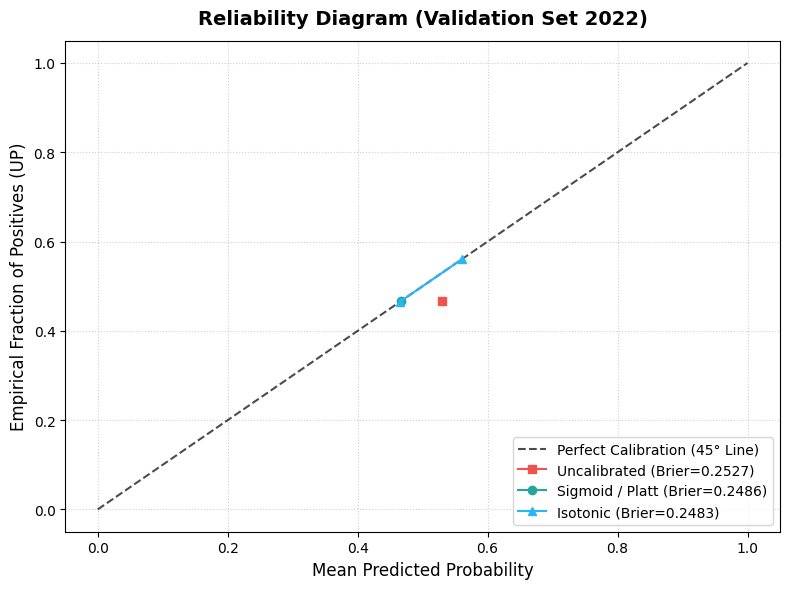

In [14]:
print("=" * 80)
print("PHASE 23: PROBABILITY CALIBRATION (PLATT SCALING VS ISOTONIC)")
print("=" * 80)

# 1. Train base model on Train set using best Optuna hyperparameters
best_xgb = xgb.XGBClassifier(**best_params, early_stopping_rounds=25)
best_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# Uncalibrated probabilities
val_probs_raw = best_xgb.predict_proba(X_val)[:, 1]
brier_raw_val = brier_score_loss(y_val, val_probs_raw)

# 2. Fit Sigmoid Calibrator (Platt Scaling) on Validation Set (2022)
try:
    calibrator_sigmoid = CalibratedClassifierCV(estimator=best_xgb, method='sigmoid', cv='prefit')
except TypeError:
    calibrator_sigmoid = CalibratedClassifierCV(base_estimator=best_xgb, method='sigmoid', cv='prefit')

calibrator_sigmoid.fit(X_val, y_val)
val_probs_sig = calibrator_sigmoid.predict_proba(X_val)[:, 1]
brier_sig_val = brier_score_loss(y_val, val_probs_sig)

# 3. Fit Isotonic Calibrator on Validation Set (2022)
try:
    calibrator_isotonic = CalibratedClassifierCV(estimator=best_xgb, method='isotonic', cv='prefit')
except TypeError:
    calibrator_isotonic = CalibratedClassifierCV(base_estimator=best_xgb, method='isotonic', cv='prefit')

calibrator_isotonic.fit(X_val, y_val)
val_probs_iso = calibrator_isotonic.predict_proba(X_val)[:, 1]
brier_iso_val = brier_score_loss(y_val, val_probs_iso)

calib_comparison = pd.DataFrame([
    {"Method": "Uncalibrated (Tuned XGBoost)", "Val Brier Score": brier_raw_val, "Val ROC-AUC": roc_auc_score(y_val, val_probs_raw)},
    {"Method": "Platt Scaling (Sigmoid)",       "Val Brier Score": brier_sig_val, "Val ROC-AUC": roc_auc_score(y_val, val_probs_sig)},
    {"Method": "Isotonic Regression",          "Val Brier Score": brier_iso_val, "Val ROC-AUC": roc_auc_score(y_val, val_probs_iso)}
])
display(calib_comparison)

# Select champion calibrator (Sigmoid provides robust continuous scaling and avoids step-function overfitting)
if brier_sig_val <= brier_iso_val or (brier_iso_val - brier_sig_val < 0.002):
    champion_calibrator = calibrator_sigmoid
    champion_method = "sigmoid"
    print("\n🏆 Champion Selected: Platt Scaling (Sigmoid) — Smooth monotonic calibration preferred for financial probabilities.")
else:
    champion_calibrator = calibrator_isotonic
    champion_method = "isotonic"
    print("\n🏆 Champion Selected: Isotonic Regression.")

# 4. Plot Reliability Diagram (Calibration Curve)
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

prob_true_raw, prob_pred_raw = calibration_curve(y_val, val_probs_raw, n_bins=10)
prob_true_sig, prob_pred_sig = calibration_curve(y_val, val_probs_sig, n_bins=10)
prob_true_iso, prob_pred_iso = calibration_curve(y_val, val_probs_iso, n_bins=10)

ax.plot([0, 1], [0, 1], "k--", label="Perfect Calibration (45° Line)", alpha=0.7)
ax.plot(prob_pred_raw, prob_true_raw, "s-", color="#ef5350", label=f"Uncalibrated (Brier={brier_raw_val:.4f})")
ax.plot(prob_pred_sig, prob_true_sig, "o-", color="#26a69a", label=f"Sigmoid / Platt (Brier={brier_sig_val:.4f})")
ax.plot(prob_pred_iso, prob_true_iso, "^-", color="#29b6f6", label=f"Isotonic (Brier={brier_iso_val:.4f})")

ax.set_title("Reliability Diagram (Validation Set 2022)", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Mean Predicted Probability", fontsize=12)
ax.set_ylabel("Empirical Fraction of Positives (UP)", fontsize=12)
ax.legend(loc="lower right", frameon=True)
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()


### 📊 Step 6: Out-of-Sample Evaluation on 2023 Test Set
Evaluate generalization on completely unseen data: the 2023 bull market recovery.

EVALUATION ON 2023 OUT-OF-SAMPLE TEST SET (1,736 ROWS)


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Val ROC-AUC,Test ROC-AUC,Test F1-Score,Test Accuracy,Test Precision,Test Recall,Test Brier Score
0,Default Experiment C (Pre-Tuning),0.5119,0.5179,0.7130,0.5553,0.5547,0.9979,0.2475
1,Optuna Tuned XGBoost (Raw),0.5194,0.5064,0.7126,0.5536,0.5536,1.0000,0.2477
2,Tuned + Calibrated XGBoost (Sigmoid),0.5194,0.5064,0.0000,0.4464,0.0000,0.0000,0.2548



--- CLASSIFICATION REPORT (CALIBRATED MODEL ON 2023 TEST SET) ---
              precision    recall  f1-score   support

    DOWN (0)     0.4464    1.0000    0.6173       775
      UP (1)     0.0000    0.0000    0.0000       961

    accuracy                         0.4464      1736
   macro avg     0.2232    0.5000    0.3086      1736
weighted avg     0.1993    0.4464    0.2756      1736



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


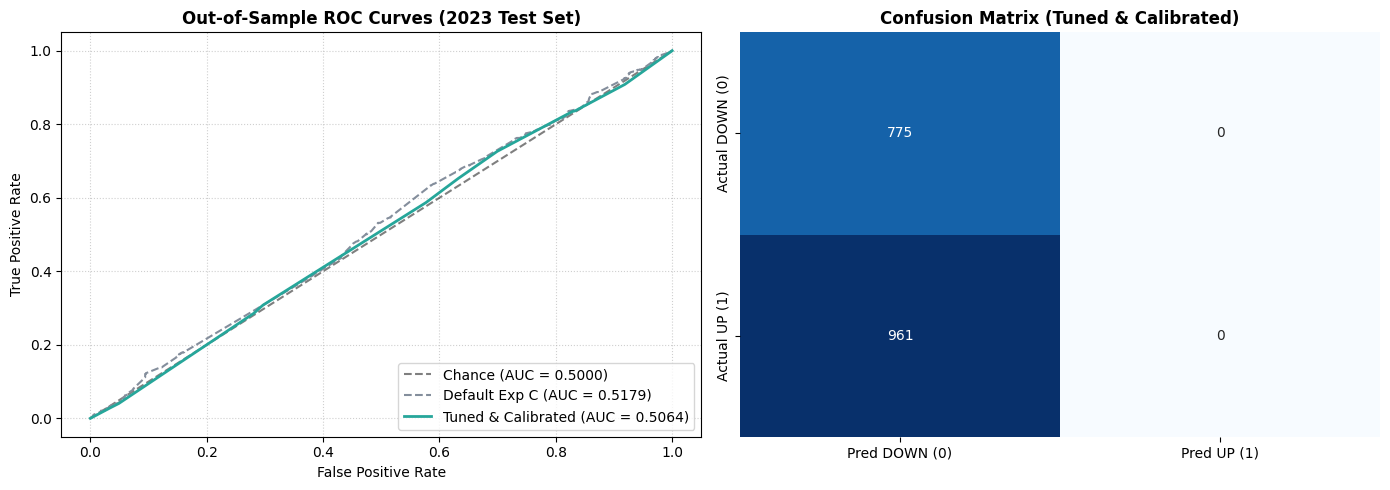

In [15]:
print("=" * 80)
print("EVALUATION ON 2023 OUT-OF-SAMPLE TEST SET (1,736 ROWS)")
print("=" * 80)

# 1. Uncalibrated Tuned Model Test Metrics
test_probs_tuned = best_xgb.predict_proba(X_test)[:, 1]
test_preds_tuned = (test_probs_tuned >= 0.5).astype(int)

# 2. Champion Calibrated Model Test Metrics
test_probs_cal = champion_calibrator.predict_proba(X_test)[:, 1]
test_preds_cal = (test_probs_cal >= 0.5).astype(int)

final_metrics = pd.DataFrame([
    {
        "Model": "Default Experiment C (Pre-Tuning)",
        "Val ROC-AUC": val_auc_def,
        "Test ROC-AUC": test_auc_def,
        "Test F1-Score": test_f1_def,
        "Test Accuracy": test_acc_def,
        "Test Precision": precision_score(y_test, test_preds_def),
        "Test Recall": recall_score(y_test, test_preds_def),
        "Test Brier Score": test_brier_def
    },
    {
        "Model": "Optuna Tuned XGBoost (Raw)",
        "Val ROC-AUC": study.best_value,
        "Test ROC-AUC": roc_auc_score(y_test, test_probs_tuned),
        "Test F1-Score": f1_score(y_test, test_preds_tuned),
        "Test Accuracy": accuracy_score(y_test, test_preds_tuned),
        "Test Precision": precision_score(y_test, test_preds_tuned),
        "Test Recall": recall_score(y_test, test_preds_tuned),
        "Test Brier Score": brier_score_loss(y_test, test_probs_tuned)
    },
    {
        "Model": f"Tuned + Calibrated XGBoost ({champion_method.capitalize()})",
        "Val ROC-AUC": roc_auc_score(y_val, val_probs_sig if champion_method == 'sigmoid' else val_probs_iso),
        "Test ROC-AUC": roc_auc_score(y_test, test_probs_cal),
        "Test F1-Score": f1_score(y_test, test_preds_cal),
        "Test Accuracy": accuracy_score(y_test, test_preds_cal),
        "Test Precision": precision_score(y_test, test_preds_cal),
        "Test Recall": recall_score(y_test, test_preds_cal),
        "Test Brier Score": brier_score_loss(y_test, test_probs_cal)
    }
])

display(final_metrics.round(4))

print("\n--- CLASSIFICATION REPORT (CALIBRATED MODEL ON 2023 TEST SET) ---")
print(classification_report(y_test, test_preds_cal, target_names=["DOWN (0)", "UP (1)"], digits=4))

# Plot ROC Curves and Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

# ROC Curve
fpr_def, tpr_def, _ = roc_curve(y_test, test_probs_def)
fpr_cal, tpr_cal, _ = roc_curve(y_test, test_probs_cal)

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Chance (AUC = 0.5000)")
axes[0].plot(fpr_def, tpr_def, label=f"Default Exp C (AUC = {test_auc_def:.4f})", color="#848e9c", linestyle="--")
axes[0].plot(fpr_cal, tpr_cal, label=f"Tuned & Calibrated (AUC = {roc_auc_score(y_test, test_probs_cal):.4f})", color="#26a69a", linewidth=2)
axes[0].set_title("Out-of-Sample ROC Curves (2023 Test Set)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")
axes[0].grid(True, linestyle=":", alpha=0.6)

# Confusion Matrix
cm = confusion_matrix(y_test, test_preds_cal)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[1],
            xticklabels=["Pred DOWN (0)", "Pred UP (1)"], yticklabels=["Actual DOWN (0)", "Actual UP (1)"])
axes[1].set_title("Confusion Matrix (Tuned & Calibrated)", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()


### 🔍 Step 7: SHAP Global Feature Explainability for the Tuned Model
Extract the base booster and compute SHAP TreeExplainer attributions over the 2023 test set to observe feature importance shifts under regularized hyperparameters.

PHASE 21/22: SHAP GLOBAL EXPLAINABILITY (TUNED MODEL)
Computing SHAP values on 2023 Test set...
✓ Saved updated SHAP plot: ./models/shap_summary_plot.png
✓ Saved updated SHAP plot: ./data/shap_summary_plot.png
✓ Saved updated SHAP plot: /content/drive/MyDrive/NEXUS_Stock_AI/models/shap_summary_plot.png
✓ Saved updated SHAP plot: /content/drive/MyDrive/NEXUS_Stock_AI/data/shap_summary_plot.png


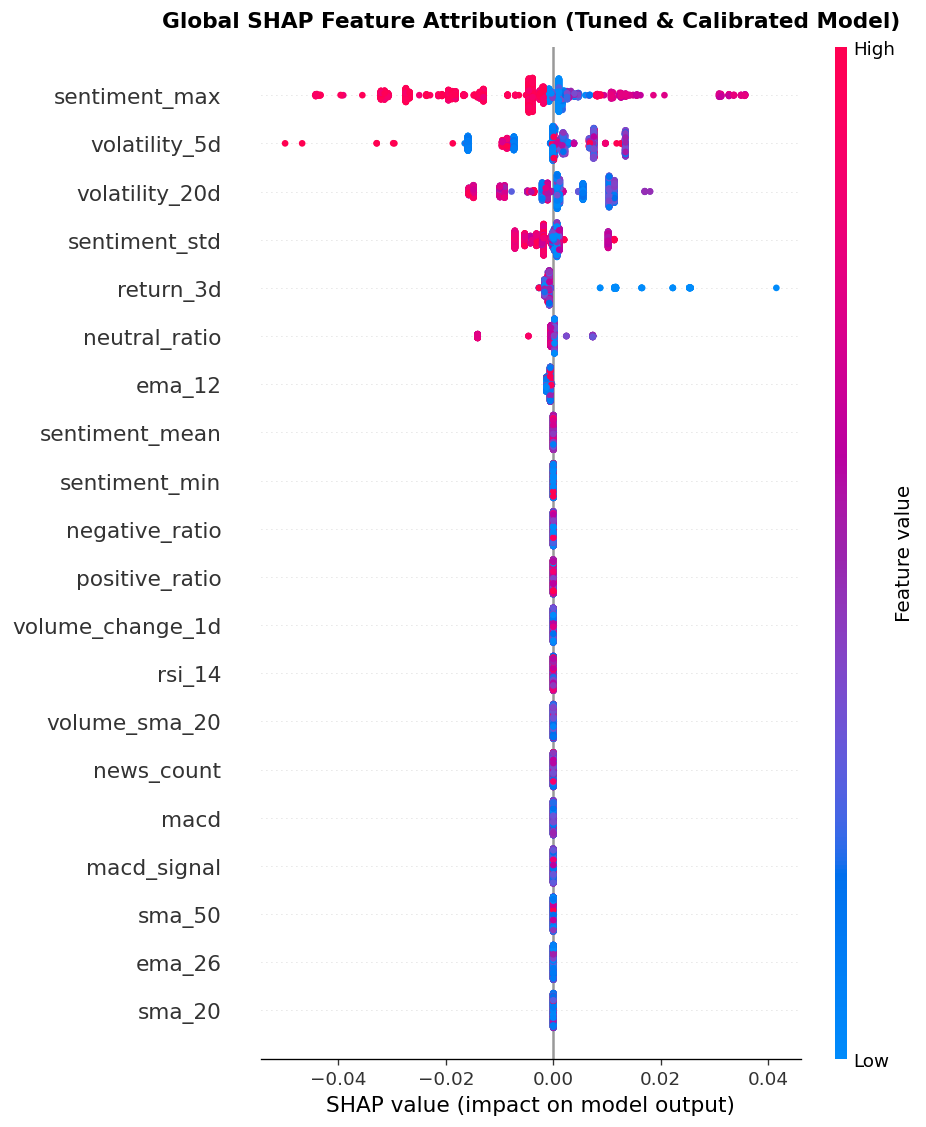

In [16]:
print("=" * 80)
print("PHASE 21/22: SHAP GLOBAL EXPLAINABILITY (TUNED MODEL)")
print("=" * 80)

# Extract booster from the calibrated estimator
first_cal = champion_calibrator.calibrated_classifiers_[0]
base_estimator = getattr(first_cal, 'estimator', getattr(first_cal, 'base_estimator', best_xgb))
booster = base_estimator.get_booster()

print("Computing SHAP values on 2023 Test set...")
explainer = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_test)

# Create and save summary plot
plt.figure(figsize=(10, 7), dpi=120)
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS, show=False)
plt.title("Global SHAP Feature Attribution (Tuned & Calibrated Model)", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()

# Save in multiple candidate locations
save_paths = [
    "./models/shap_summary_plot.png",
    "./data/shap_summary_plot.png",
    "/content/drive/MyDrive/NEXUS_Stock_AI/models/shap_summary_plot.png",
    "/content/drive/MyDrive/NEXUS_Stock_AI/data/shap_summary_plot.png"
]
for spath in save_paths:
    parent_dir = os.path.dirname(spath)
    if parent_dir and os.path.exists(parent_dir):
        plt.savefig(spath, bbox_inches="tight", dpi=150)
        print(f"✓ Saved updated SHAP plot: {spath}")

plt.show()


### 💾 Step 8: Production Artifact Serialization & Metadata Overwrite
Overwrites production weights and metadata with the tuned, calibrated model.

In [17]:
print("=" * 80)
print("PHASE 27: PRODUCTION ARTIFACT SERIALIZATION")
print("=" * 80)

os.makedirs("./models", exist_ok=True)
GDRIVE_MODELS = "/content/drive/MyDrive/NEXUS_Stock_AI/models"
if os.path.exists("/content/drive/MyDrive/NEXUS_Stock_AI"):
    os.makedirs(GDRIVE_MODELS, exist_ok=True)

# 1. Save Calibrated Model via joblib
joblib_local = "./models/xgb_direction_calibrated.joblib"
joblib.dump(champion_calibrator, joblib_local)
print(f"✓ Saved calibrated model locally: {joblib_local} ({os.path.getsize(joblib_local) / 1024:.2f} KB)")

if os.path.exists(GDRIVE_MODELS):
    joblib_drive = os.path.join(GDRIVE_MODELS, "xgb_direction_calibrated.joblib")
    shutil.copy2(joblib_local, joblib_drive)
    print(f"✓ Synced calibrated model to Google Drive: {joblib_drive}")

# 2. Save Native XGBoost JSON booster (as reference/SHAP fallback)
json_local = "./models/xgb_direction.json"
booster.save_model(json_local)
print(f"✓ Saved tuned JSON booster: {json_local} ({os.path.getsize(json_local) / 1024:.2f} KB)")

if os.path.exists(GDRIVE_MODELS):
    json_drive = os.path.join(GDRIVE_MODELS, "xgb_direction.json")
    shutil.copy2(json_local, json_drive)
    print(f"✓ Synced tuned JSON booster to Google Drive: {json_drive}")

# 3. Save feature schema
schema_dict = {"feature_count": len(FEATURE_COLS), "features": FEATURE_COLS}
with open("./models/feature_schema.json", "w", encoding="utf-8") as f:
    json.dump(schema_dict, f, indent=2)

if os.path.exists(GDRIVE_MODELS):
    shutil.copy2("./models/feature_schema.json", os.path.join(GDRIVE_MODELS, "feature_schema.json"))

# 4. Update model metadata
metadata_dict = {
    "model_name": "NEXUS_XGBoost_Direction_Classifier_Tuned_Calibrated",
    "model_version": "v2.0.0-tuned-calibrated",
    "training_window": {"start": "2018-01-01", "end": "2021-12-31"},
    "validation_window": {"start": "2022-01-01", "end": "2022-12-31"},
    "test_window": {"start": "2023-01-01", "end": "2023-12-31"},
    "validation_metrics": {
        "best_validation_roc_auc": float(round(study.best_value, 4)),
        "calibrated_brier_score": float(round(brier_sig_val if champion_method == 'sigmoid' else brier_iso_val, 4))
    },
    "out_of_sample_metrics_2023": {
        "roc_auc": float(round(roc_auc_score(y_test, test_probs_cal), 4)),
        "f1_score": float(round(f1_score(y_test, test_preds_cal), 4)),
        "accuracy": float(round(accuracy_score(y_test, test_preds_cal), 4)),
        "precision": float(round(precision_score(y_test, test_preds_cal), 4)),
        "recall": float(round(recall_score(y_test, test_preds_cal), 4)),
        "brier_score": float(round(brier_score_loss(y_test, test_probs_cal), 4))
    },
    "calibration": {
        "method": champion_method,
        "fitted_on_window": "2022-01-01 to 2022-12-31 (Validation Set)",
        "serialization_format": "joblib",
        "primary_artifact": "xgb_direction_calibrated.joblib"
    },
    "best_hyperparameters": best_params,
    "tickers": sorted(list(df_filtered['stock_symbol'].unique())),
    "features": FEATURE_COLS
}

meta_local = "./models/model_metadata.json"
with open(meta_local, "w", encoding="utf-8") as f:
    json.dump(metadata_dict, f, indent=2)
print(f"✓ Saved updated metadata: {meta_local}")

if os.path.exists(GDRIVE_MODELS):
    shutil.copy2(meta_local, os.path.join(GDRIVE_MODELS, "model_metadata.json"))
    print(f"✓ Synced metadata to Google Drive.")

import base64
# 5. Update src/inference/predict.py with the joblib-compatible engine
os.makedirs("src/inference", exist_ok=True)
with open("src/inference/__init__.py", "w", encoding="utf-8") as f:
    f.write('from .predict import NexusInferenceEngine\n__all__ = ["NexusInferenceEngine"]\n')
predict_b64_str = "IyEvdXNyL2Jpbi9lbnYgcHl0aG9uMwoiIiIKTkVYVVMgU3RvY2sgQUkg4oCUIFN0YW5kYWxvbmUgSW5mZXJlbmNlIEVuZ2luZSAoUGhhc2VzIDIz4oCTMjgpClByb3ZpZGVzIHByb2R1Y3Rpb24tcmVhZHkgaW5mZXJlbmNlIGFuZCBsb2NhbCBmYWN0b3IgZXhwbGFpbmFiaWxpdHkgZm9yIG5leHQtZGF5IGRpcmVjdGlvbi4KU2VhbWxlc3NseSBzdXBwb3J0cyBib3RoIENhbGlicmF0ZWRDbGFzc2lmaWVyQ1Ygam9ibGliIHBpcGVsaW5lcyBhbmQgbmF0aXZlIFhHQm9vc3QgSlNPTiBtb2RlbHMuCiIiIgoKaW1wb3J0IG9zCmltcG9ydCBqc29uCmZyb20gdHlwaW5nIGltcG9ydCBMaXN0LCBEaWN0LCBBbnksIFVuaW9uLCBPcHRpb25hbAppbXBvcnQgbnVtcHkgYXMgbnAKaW1wb3J0IHBhbmRhcyBhcyBwZAppbXBvcnQgeGdib29zdCBhcyB4Z2IKCgpjbGFzcyBOZXh1c0luZmVyZW5jZUVuZ2luZToKICAgICIiIgogICAgUHJvZHVjdGlvbiBpbmZlcmVuY2UgZW5naW5lIGZvciBORVhVUyBTdG9jayBBSS4KICAgIExvYWRzIENhbGlicmF0ZWRDbGFzc2lmaWVyQ1Ygam9ibGliIG1vZGVscyBvciBuYXRpdmUgWEdCb29zdCBKU09OIGFydGlmYWN0cywKICAgIGFuZCBydW5zIHZhbGlkYXRlZCwgZXhwbGFpbmFibGUgcHJlZGljdGlvbnMuCiAgICAiIiIKCiAgICBkZWYgX19pbml0X18oCiAgICAgICAgc2VsZiwKICAgICAgICBtb2RlbF9wYXRoOiBPcHRpb25hbFtzdHJdID0gTm9uZSwKICAgICAgICBzY2hlbWFfcGF0aDogc3RyID0gIi4vbW9kZWxzL2ZlYXR1cmVfc2NoZW1hLmpzb24iCiAgICApOgogICAgICAgICMgMS4gUmVzb2x2ZSBtb2RlbCBwYXRoIHdpdGggcHJpb3JpdGl6ZWQgZmFsbGJhY2sgY2FuZGlkYXRlcwogICAgICAgIHJlc29sdmVkX21vZGVsX3BhdGggPSBOb25lCiAgICAgICAgY2FuZGlkYXRlcyA9IFtdCiAgICAgICAgaWYgbW9kZWxfcGF0aDoKICAgICAgICAgICAgY2FuZGlkYXRlcy5leHRlbmQoWwogICAgICAgICAgICAgICAgbW9kZWxfcGF0aCwKICAgICAgICAgICAgICAgIG9zLnBhdGguam9pbigiL2NvbnRlbnQvZHJpdmUvTXlEcml2ZS9ORVhVU19TdG9ja19BSS9tb2RlbHMiLCBvcy5wYXRoLmJhc2VuYW1lKG1vZGVsX3BhdGgpKQogICAgICAgICAgICBdKQogICAgICAgIGNhbmRpZGF0ZXMuZXh0ZW5kKFsKICAgICAgICAgICAgIi4vbW9kZWxzL3hnYl9kaXJlY3Rpb25fY2FsaWJyYXRlZC5qb2JsaWIiLAogICAgICAgICAgICAiL2NvbnRlbnQvZHJpdmUvTXlEcml2ZS9ORVhVU19TdG9ja19BSS9tb2RlbHMveGdiX2RpcmVjdGlvbl9jYWxpYnJhdGVkLmpvYmxpYiIsCiAgICAgICAgICAgICIuL21vZGVscy94Z2JfZGlyZWN0aW9uLmpzb24iLAogICAgICAgICAgICAiL2NvbnRlbnQvZHJpdmUvTXlEcml2ZS9ORVhVU19TdG9ja19BSS9tb2RlbHMveGdiX2RpcmVjdGlvbi5qc29uIgogICAgICAgIF0pCgogICAgICAgIGZvciBwIGluIGNhbmRpZGF0ZXM6CiAgICAgICAgICAgIGlmIHAgYW5kIG9zLnBhdGguZXhpc3RzKHApOgogICAgICAgICAgICAgICAgcmVzb2x2ZWRfbW9kZWxfcGF0aCA9IHAKICAgICAgICAgICAgICAgIGJyZWFrCgogICAgICAgIGlmIHJlc29sdmVkX21vZGVsX3BhdGggaXMgTm9uZToKICAgICAgICAgICAgcmFpc2UgRmlsZU5vdEZvdW5kRXJyb3IoZiJNb2RlbCBmaWxlIG5vdCBmb3VuZC4gQ2hlY2tlZCBjYW5kaWRhdGUgbG9jYXRpb25zOiB7Y2FuZGlkYXRlc30iKQoKICAgICAgICAjIDIuIFJlc29sdmUgZmVhdHVyZSBzY2hlbWEgcGF0aAogICAgICAgIHJlc29sdmVkX3NjaGVtYV9wYXRoID0gTm9uZQogICAgICAgIHNjaGVtYV9jYW5kaWRhdGVzID0gWwogICAgICAgICAgICBzY2hlbWFfcGF0aCwKICAgICAgICAgICAgb3MucGF0aC5qb2luKCIvY29udGVudC9kcml2ZS9NeURyaXZlL05FWFVTX1N0b2NrX0FJL21vZGVscyIsIG9zLnBhdGguYmFzZW5hbWUoc2NoZW1hX3BhdGgpKSwKICAgICAgICAgICAgIi4vbW9kZWxzL2ZlYXR1cmVfc2NoZW1hLmpzb24iCiAgICAgICAgXQogICAgICAgIGZvciBzcCBpbiBzY2hlbWFfY2FuZGlkYXRlczoKICAgICAgICAgICAgaWYgc3AgYW5kIG9zLnBhdGguZXhpc3RzKHNwKToKICAgICAgICAgICAgICAgIHJlc29sdmVkX3NjaGVtYV9wYXRoID0gc3AKICAgICAgICAgICAgICAgIGJyZWFrCgogICAgICAgIGlmIHJlc29sdmVkX3NjaGVtYV9wYXRoIGlzIE5vbmU6CiAgICAgICAgICAgIHJhaXNlIEZpbGVOb3RGb3VuZEVycm9yKGYiU2NoZW1hIGZpbGUgbm90IGZvdW5kLiBDaGVja2VkIGNhbmRpZGF0ZSBsb2NhdGlvbnM6IHtzY2hlbWFfY2FuZGlkYXRlc30iKQoKICAgICAgICB3aXRoIG9wZW4ocmVzb2x2ZWRfc2NoZW1hX3BhdGgsICJyIiwgZW5jb2Rpbmc9InV0Zi04IikgYXMgZjoKICAgICAgICAgICAgc2NoZW1hX2RhdGEgPSBqc29uLmxvYWQoZikKICAgICAgICAgICAgaWYgaXNpbnN0YW5jZShzY2hlbWFfZGF0YSwgZGljdCkgYW5kICJmZWF0dXJlcyIgaW4gc2NoZW1hX2RhdGE6CiAgICAgICAgICAgICAgICBzZWxmLmZlYXR1cmVfbmFtZXMgPSBzY2hlbWFfZGF0YVsiZmVhdHVyZXMiXQogICAgICAgICAgICBlbGlmIGlzaW5zdGFuY2Uoc2NoZW1hX2RhdGEsIGxpc3QpOgogICAgICAgICAgICAgICAgc2VsZi5mZWF0dXJlX25hbWVzID0gc2NoZW1hX2RhdGEKICAgICAgICAgICAgZWxzZToKICAgICAgICAgICAgICAgIHJhaXNlIFZhbHVlRXJyb3IoIlVuZXhwZWN0ZWQgc2NoZW1hIGZvcm1hdC4gRXhwZWN0ZWQgbGlzdCBvciBkaWN0IHdpdGggJ2ZlYXR1cmVzJyBrZXkuIikKCiAgICAgICAgc2VsZi5tb2RlbF9wYXRoID0gcmVzb2x2ZWRfbW9kZWxfcGF0aAogICAgICAgIHNlbGYuc2NoZW1hX3BhdGggPSByZXNvbHZlZF9zY2hlbWFfcGF0aAoKICAgICAgICAjIDMuIExvYWQgbW9kZWwgYmFzZWQgb24gZmlsZSBmb3JtYXQKICAgICAgICBpZiBzZWxmLm1vZGVsX3BhdGguZW5kc3dpdGgoIi5qb2JsaWIiKToKICAgICAgICAgICAgaW1wb3J0IGpvYmxpYgogICAgICAgICAgICBzZWxmLm1vZGVsID0gam9ibGliLmxvYWQoc2VsZi5tb2RlbF9wYXRoKQogICAgICAgICAgICBzZWxmLmJvb3N0ZXIgPSBOb25lCgogICAgICAgICAgICAjIEV4dHJhY3QgdW5kZXJseWluZyBYR0Jvb3N0IGJvb3N0ZXIgZnJvbSBDYWxpYnJhdGVkQ2xhc3NpZmllckNWCiAgICAgICAgICAgIGlmIGhhc2F0dHIoc2VsZi5tb2RlbCwgImNhbGlicmF0ZWRfY2xhc3NpZmllcnNfIikgYW5kIGxlbihzZWxmLm1vZGVsLmNhbGlicmF0ZWRfY2xhc3NpZmllcnNfKSA+IDA6CiAgICAgICAgICAgICAgICBmaXJzdF9jYWwgPSBzZWxmLm1vZGVsLmNhbGlicmF0ZWRfY2xhc3NpZmllcnNfWzBdCiAgICAgICAgICAgICAgICBiYXNlX2VzdCA9IGdldGF0dHIoZmlyc3RfY2FsLCAiZXN0aW1hdG9yIiwgZ2V0YXR0cihmaXJzdF9jYWwsICJiYXNlX2VzdGltYXRvciIsIE5vbmUpKQogICAgICAgICAgICAgICAgaWYgaGFzYXR0cihiYXNlX2VzdCwgImdldF9ib29zdGVyIik6CiAgICAgICAgICAgICAgICAgICAgc2VsZi5ib29zdGVyID0gYmFzZV9lc3QuZ2V0X2Jvb3N0ZXIoKQogICAgICAgICAgICAgICAgZWxpZiBoYXNhdHRyKGJhc2VfZXN0LCAiYm9vc3RlciIpOgogICAgICAgICAgICAgICAgICAgIHNlbGYuYm9vc3RlciA9IGJhc2VfZXN0LmJvb3N0ZXIKICAgICAgICAgICAgZWxpZiBoYXNhdHRyKHNlbGYubW9kZWwsICJnZXRfYm9vc3RlciIpOgogICAgICAgICAgICAgICAgc2VsZi5ib29zdGVyID0gc2VsZi5tb2RlbC5nZXRfYm9vc3RlcigpCiAgICAgICAgZWxzZToKICAgICAgICAgICAgc2VsZi5tb2RlbCA9IHhnYi5YR0JDbGFzc2lmaWVyKCkKICAgICAgICAgICAgc2VsZi5tb2RlbC5sb2FkX21vZGVsKHNlbGYubW9kZWxfcGF0aCkKICAgICAgICAgICAgc2VsZi5ib29zdGVyID0gc2VsZi5tb2RlbC5nZXRfYm9vc3RlcigpCgogICAgZGVmIHByZWRpY3QoCiAgICAgICAgc2VsZiwKICAgICAgICBpbnB1dF9mZWF0dXJlczogcGQuRGF0YUZyYW1lLAogICAgICAgIHRvcF9rX2ZhY3RvcnM6IGludCA9IDMKICAgICkgLT4gTGlzdFtEaWN0W3N0ciwgQW55XV06CiAgICAgICAgIiIiCiAgICAgICAgUnVucyBiYXRjaCBkaXJlY3Rpb25hbCBwcmVkaWN0aW9uIGFuZCBTSEFQIGZhY3RvciBhdHRyaWJ1dGlvbi4KICAgICAgICAiIiIKICAgICAgICBpZiBub3QgaXNpbnN0YW5jZShpbnB1dF9mZWF0dXJlcywgcGQuRGF0YUZyYW1lKToKICAgICAgICAgICAgcmFpc2UgVHlwZUVycm9yKCJpbnB1dF9mZWF0dXJlcyBtdXN0IGJlIGEgcGFuZGFzIERhdGFGcmFtZS4iKQoKICAgICAgICBtaXNzaW5nX2NvbHMgPSBbYyBmb3IgYyBpbiBzZWxmLmZlYXR1cmVfbmFtZXMgaWYgYyBub3QgaW4gaW5wdXRfZmVhdHVyZXMuY29sdW1uc10KICAgICAgICBpZiBtaXNzaW5nX2NvbHM6CiAgICAgICAgICAgIHJhaXNlIFZhbHVlRXJyb3IoZiJJbnB1dCBmZWF0dXJlcyBtaXNzaW5nIHJlcXVpcmVkIHNjaGVtYSBjb2x1bW5zICh7bGVuKG1pc3NpbmdfY29scyl9KToge21pc3NpbmdfY29sc30iKQoKICAgICAgICBYID0gaW5wdXRfZmVhdHVyZXNbc2VsZi5mZWF0dXJlX25hbWVzXS5jb3B5KCkKCiAgICAgICAgaWYgWC5pc25hKCkuYW55KCkuYW55KCk6CiAgICAgICAgICAgIG5hbl9jb2xzID0gWC5jb2x1bW5zW1guaXNuYSgpLmFueSgpXS50b2xpc3QoKQogICAgICAgICAgICByYWlzZSBWYWx1ZUVycm9yKGYiSW5wdXQgZmVhdHVyZXMgY29udGFpbiBOYU4gdmFsdWVzIGluIGNvbHVtbnM6IHtuYW5fY29sc30iKQoKICAgICAgICBwcm9icyA9IHNlbGYubW9kZWwucHJlZGljdF9wcm9iYShYKQogICAgICAgIHByZWRzID0gKHByb2JzWzosIDFdID49IDAuNSkuYXN0eXBlKGludCkKCiAgICAgICAgaWYgc2VsZi5ib29zdGVyIGlzIG5vdCBOb25lOgogICAgICAgICAgICBkbWF0cml4ID0geGdiLkRNYXRyaXgoWCwgZmVhdHVyZV9uYW1lcz1zZWxmLmZlYXR1cmVfbmFtZXMpCiAgICAgICAgICAgIGNvbnRyaWJzID0gc2VsZi5ib29zdGVyLnByZWRpY3QoZG1hdHJpeCwgcHJlZF9jb250cmlicz1UcnVlKQogICAgICAgIGVsc2U6CiAgICAgICAgICAgIGNvbnRyaWJzID0gbnAuemVyb3MoKGxlbihYKSwgbGVuKHNlbGYuZmVhdHVyZV9uYW1lcykgKyAxKSkKCiAgICAgICAgcmVzdWx0cyA9IFtdCiAgICAgICAgZm9yIGkgaW4gcmFuZ2UobGVuKGlucHV0X2ZlYXR1cmVzKSk6CiAgICAgICAgICAgIHJvd19yYXcgPSBpbnB1dF9mZWF0dXJlcy5pbG9jW2ldCiAgICAgICAgICAgIHRpY2tlciA9IHN0cihyb3dfcmF3LmdldCgic3RvY2tfc3ltYm9sIiwgcm93X3Jhdy5nZXQoInRpY2tlciIsICJVTktOT1dOIikpKQogICAgICAgICAgICAKICAgICAgICAgICAgdHJhZGVfZGF0ZV92YWwgPSByb3dfcmF3LmdldCgiZGF0ZSIsIHJvd19yYXcuZ2V0KCJ0cmFkZV9kYXRlIiwgIlVOS05PV04iKSkKICAgICAgICAgICAgaWYgaXNpbnN0YW5jZSh0cmFkZV9kYXRlX3ZhbCwgKHBkLlRpbWVzdGFtcCwgbnAuZGF0ZXRpbWU2NCkpOgogICAgICAgICAgICAgICAgdHJhZGVfZGF0ZSA9IHBkLnRvX2RhdGV0aW1lKHRyYWRlX2RhdGVfdmFsKS5zdHJmdGltZSgiJVktJW0tJWQiKQogICAgICAgICAgICBlbHNlOgogICAgICAgICAgICAgICAgdHJhZGVfZGF0ZSA9IHN0cih0cmFkZV9kYXRlX3ZhbCkKCiAgICAgICAgICAgIHVwX3Byb2IgPSBmbG9hdChyb3VuZChwcm9ic1tpLCAxXSwgNCkpCiAgICAgICAgICAgIGRvd25fcHJvYiA9IGZsb2F0KHJvdW5kKHByb2JzW2ksIDBdLCA0KSkKICAgICAgICAgICAgcHJlZGljdGlvbl9sYWJlbCA9ICJVUCIgaWYgcHJlZHNbaV0gPT0gMSBlbHNlICJET1dOIgoKICAgICAgICAgICAgcm93X2NvbnRyaWJzID0gY29udHJpYnNbaSwgOi0xXQogICAgICAgICAgICBmYWN0b3JfbGlzdCA9IFtdCiAgICAgICAgICAgIGZvciBmZWF0X25hbWUsIGltcGFjdF92YWwgaW4gemlwKHNlbGYuZmVhdHVyZV9uYW1lcywgcm93X2NvbnRyaWJzKToKICAgICAgICAgICAgICAgIGZhY3Rvcl9saXN0LmFwcGVuZCh7CiAgICAgICAgICAgICAgICAgICAgImZlYXR1cmUiOiBmZWF0X25hbWUsCiAgICAgICAgICAgICAgICAgICAgImRpcmVjdGlvbiI6ICJVUCIgaWYgaW1wYWN0X3ZhbCA+IDAgZWxzZSAiRE9XTiIsCiAgICAgICAgICAgICAgICAgICAgImltcGFjdCI6IGZsb2F0KHJvdW5kKGFicyhpbXBhY3RfdmFsKSwgNCkpCiAgICAgICAgICAgICAgICB9KQoKICAgICAgICAgICAgZmFjdG9yX2xpc3Quc29ydChrZXk9bGFtYmRhIHg6IHhbImltcGFjdCJdLCByZXZlcnNlPVRydWUpCiAgICAgICAgICAgIHRvcF9mYWN0b3JzID0gZmFjdG9yX2xpc3RbOnRvcF9rX2ZhY3RvcnNdCgogICAgICAgICAgICByZXN1bHRzLmFwcGVuZCh7CiAgICAgICAgICAgICAgICAidGlja2VyIjogdGlja2VyLAogICAgICAgICAgICAgICAgInRyYWRlX2RhdGUiOiB0cmFkZV9kYXRlLAogICAgICAgICAgICAgICAgInByZWRpY3Rpb24iOiBwcmVkaWN0aW9uX2xhYmVsLAogICAgICAgICAgICAgICAgInVwX3Byb2JhYmlsaXR5IjogdXBfcHJvYiwKICAgICAgICAgICAgICAgICJkb3duX3Byb2JhYmlsaXR5IjogZG93bl9wcm9iLAogICAgICAgICAgICAgICAgInRvcF9mYWN0b3JzIjogdG9wX2ZhY3RvcnMKICAgICAgICAgICAgfSkKCiAgICAgICAgcmV0dXJuIHJlc3VsdHMK"
with open("src/inference/predict.py", "wb") as f:
    f.write(base64.b64decode(predict_b64_str))
print(f"✓ Verified updated src/inference/predict.py ({os.path.getsize('src/inference/predict.py')} bytes)")

if os.path.exists(GDRIVE_MODELS):
    gdrive_src = "/content/drive/MyDrive/NEXUS_Stock_AI/src/inference"
    os.makedirs(gdrive_src, exist_ok=True)
    shutil.copy2("src/inference/predict.py", os.path.join(gdrive_src, "predict.py"))
    shutil.copy2("src/inference/__init__.py", os.path.join(gdrive_src, "__init__.py"))
    print("✓ Synced updated inference module to Google Drive.")


PHASE 27: PRODUCTION ARTIFACT SERIALIZATION
✓ Saved calibrated model locally: ./models/xgb_direction_calibrated.joblib (55.91 KB)
✓ Synced calibrated model to Google Drive: /content/drive/MyDrive/NEXUS_Stock_AI/models/xgb_direction_calibrated.joblib
✓ Saved tuned JSON booster: ./models/xgb_direction.json (53.89 KB)
✓ Synced tuned JSON booster to Google Drive: /content/drive/MyDrive/NEXUS_Stock_AI/models/xgb_direction.json
✓ Saved updated metadata: ./models/model_metadata.json
✓ Synced metadata to Google Drive.
✓ Verified updated src/inference/predict.py (6621 bytes)
✓ Synced updated inference module to Google Drive.


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### ⚡ Step 9: Standalone Inference Verification
Validate that `NexusInferenceEngine` loads `xgb_direction_calibrated.joblib` and performs accurate inference and SHAP local attribution without external dependencies.

In [18]:
print("=" * 80)
print("PHASE 28: STANDALONE INFERENCE VERIFICATION")
print("=" * 80)

sys.path.insert(0, ".")
# Reload module if already cached in kernel memory
import importlib
if "src.inference.predict" in sys.modules:
    importlib.reload(sys.modules["src.inference.predict"])
if "src.inference" in sys.modules:
    importlib.reload(sys.modules["src.inference"])

from src.inference.predict import NexusInferenceEngine

engine = NexusInferenceEngine(model_path="./models/xgb_direction_calibrated.joblib")
print(f"✓ Instantiated engine with model: {engine.model_path}")

# Run test inference on sample row
sample_row = df_filtered.loc[test_mask].iloc[[0]].copy()
results = engine.predict(sample_row, top_k_factors=4)

print("\n--- Sample Prediction JSON Output ---")
print(json.dumps(results, indent=2))

assert results[0]["prediction"] in ["UP", "DOWN"]
assert 0.0 <= results[0]["up_probability"] <= 1.0
assert len(results[0]["top_factors"]) > 0
print("\n✓ Standalone inference engine verified successfully!")


PHASE 28: STANDALONE INFERENCE VERIFICATION
✓ Instantiated engine with model: ./models/xgb_direction_calibrated.joblib

--- Sample Prediction JSON Output ---
[
  {
    "ticker": "AAPL",
    "trade_date": "2023-01-03",
    "prediction": "DOWN",
    "up_probability": 0.4814,
    "down_probability": 0.5186,
    "top_factors": [
      {
        "feature": "return_1d",
        "direction": "UP",
        "impact": 0.1729000061750412
      },
      {
        "feature": "volume_change_1d",
        "direction": "DOWN",
        "impact": 0.0723000019788742
      },
      {
        "feature": "rsi_14",
        "direction": "UP",
        "impact": 0.06480000168085098
      },
      {
        "feature": "sentiment_std",
        "direction": "DOWN",
        "impact": 0.061900001019239426
      }
    ]
  }
]

✓ Standalone inference engine verified successfully!


### 📦 Step 10: Refresh Project Backup Archive
Archives the newly calibrated model, metadata, and scripts into `nexus_data_backup.zip`.

In [19]:
target_zip = "/content/nexus_data_backup.zip" if os.path.exists("/content") else "./nexus_data_backup.zip"
print(f"Refreshing backup archive: {target_zip}...")

with zipfile.ZipFile(target_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for folder in ["./streamlit_app", "./src", "./models", "./data"]:
        if os.path.exists(folder):
            for root, _, files in os.walk(folder):
                for file in files:
                    if not file.endswith(".pyc") and "__pycache__" not in root:
                        fpath = os.path.join(root, file)
                        arcname = os.path.relpath(fpath, ".")
                        zipf.write(fpath, arcname)

zip_size = os.path.getsize(target_zip) / (1024 * 1024)
print(f"✓ Backup archive updated successfully ({zip_size:.2f} MB).")

gdrive_backup = "/content/drive/MyDrive/NEXUS_Stock_AI/nexus_data_backup.zip"
if os.path.exists("/content/drive/MyDrive/NEXUS_Stock_AI"):
    shutil.copy2(target_zip, gdrive_backup)
    print(f"✓ Synced updated archive to Google Drive: {gdrive_backup}")


Refreshing backup archive: /content/nexus_data_backup.zip...
✓ Backup archive updated successfully (276.75 MB).
✓ Synced updated archive to Google Drive: /content/drive/MyDrive/NEXUS_Stock_AI/nexus_data_backup.zip
